# Week 3 assignment

Tämän viikon tehtävänä on kokeilla esiopetettujen verkkoja ja käsitellä kuvadataa.

Ensimmäiseksi haen CIFAR-10 kuvadatasetin tarvittavilla importeilla ja lataan kuvasetti. CIFAR-10 datasetti sisältää 50,000 32x32 kokoisia värillisiä kuvia koulutusta varten ja 10,000 validointikuvia. Valokuvat on merkattu yli 10 kategoriaan.

In [100]:
import numpy as np
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16

# Loading data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()


Harjoituksessa käytän VGG16-mallia piirteiden irrottamiseen datasetille. Alkuun käytän "preprocess_input" funktiota, varmistakseen, että pikseliarvot skaalataan oikein esikoulutetulle verkolle.


In [101]:

# Datan jakaminen harjoitus ja validointia varten
x_train = x_train_full[:40000]
y_train = y_train_full[:40000]
x_val = x_train_full[40000:]
y_val = y_train_full[40000:]

# Datan esikäsittely VGG16 varten
x_train_pre = preprocess_input(x_train.astype('float32'))
x_val_pre = preprocess_input(x_val.astype('float32'))
x_test_pre = preprocess_input(x_test.astype('float32'))

# One-hot enkoodaus
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

epoch_amount = 20
batch = 64


# Convolutional Neural Network (CNN)

Tässä koodiblokissa käytän perinteisen konvoluutioneuroverkon (CNN) vertailua varten. Käytännössä malli on rakennettu alusta asti ja ei käytä esikoulutettua dataa, vaan oppii tunnistamaan piirteet itse projektin datasta

In [102]:
from keras import Sequential, layers

model_cnn = Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Rescaling(scale=1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') ])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
cnn_start = time.time()

history_cnn = model_cnn.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = epoch_amount,
    batch_size = batch
)

cnn_end = time.time()

print(f"Training time: {cnn_end - cnn_start:.2f} seconds")
print(f"Epochs: {epoch_amount}")
print(f"Batch size: {batch}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4184 - loss: 1.5995 - val_accuracy: 0.5250 - val_loss: 1.3391
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5635 - loss: 1.2399 - val_accuracy: 0.5963 - val_loss: 1.1600
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6227 - loss: 1.0867 - val_accuracy: 0.6225 - val_loss: 1.1029
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6521 - loss: 1.0027 - val_accuracy: 0.6360 - val_loss: 1.0411
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6758 - loss: 0.9331 - val_accuracy: 0.6549 - val_loss: 0.9948
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6916 - loss: 0.8834 - val_accuracy: 0.6616 - val_loss: 0.9766
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7065 - loss: 0.8430 - val_accuracy: 0.6753 - val_loss: 0.9618
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7211 - loss: 0.7992 - val_accuracy: 0.

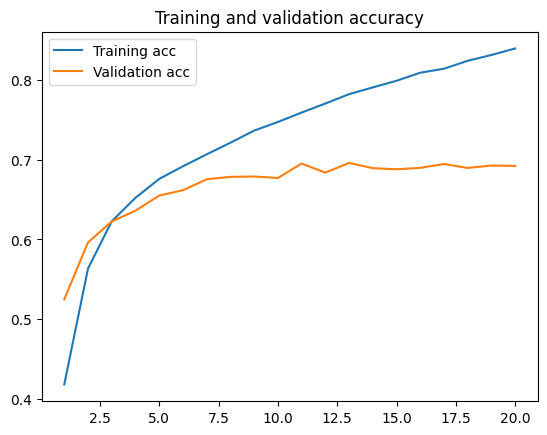

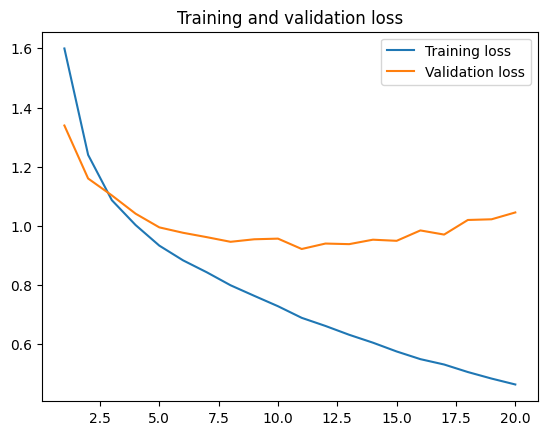

In [104]:
import matplotlib.pyplot as plt

acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# VGG16

Seuraavaksi lataan VGG16 mallin ilman yläosan luokittelijaa parametrin "include_top=False" avulla. Tämä sen takia, koska haluan käyttää mallin valmiiksi oppimia konvoluutiokerroksia (Feature Extractor), jotka osaavat tunnistaa kuvia yleisiä muotoja, kuten reunoja ja värejä.

Jätän alkuperäisen luokittelijan pois, jotta voin korvata sen omalla tiheällä verkolla, joka on räätälöity nimenomaan CIFAR-10 datasetin eri luokille.

In [105]:
model_vgg = VGG16(
                  weights='imagenet',
                  include_top=False,
                  input_shape=(32, 32, 3)
                  )

model_vgg.trainable = False
model_vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Tässä irrotan piirteet (Fast Feature Extraction) VGG16 luokkitelijaa varten ja tallennan ne.

In [106]:
def extract_features(dataset, sample_count):
    # VGG16 ulostulo 32x32 syötteellä on (batch, 1, 1, 512)
    features = np.zeros(shape=(sample_count, 1, 1, 512))
    labels = np.zeros(shape=(sample_count, 10))

    features = model_vgg.predict(dataset)
    return features

x_train_features = extract_features(x_train_pre, 40000)
x_val_features = extract_features(x_val_pre, 10000)
x_test_features = extract_features(x_test_pre, 10000)

# Litistetään piirteet luokittelijaa varten
x_train_features = np.reshape(x_train_features, (40000, 1 * 1 * 512))
x_val_features = np.reshape(x_val_features, (10000, 1 * 1 * 512))
x_test_features = np.reshape(x_test_features, (10000, 1 * 1 * 512))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


Seuraavaksi rakennan yksinkertaisen tiheän verkon (Fully Connected), joka oppii tunnistamaan lajit piirteistä

In [107]:
from tensorflow.keras import models, layers, optimizers

vgg_start = time.time()

model = models.Sequential([
    layers.Dense(256, activation='relu', input_dim=1 * 1 * 512),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=2e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_vgg = model.fit(x_train_features, y_train,
                    epochs=epoch_amount,
                    batch_size=batch,
                    validation_data=(x_val_features, y_val))

vgg_end = time.time()

print(f"Training time: {vgg_end - vgg_start:.2f} seconds")
print(f"Epochs: {epoch_amount}")
print(f"Batch size: {batch}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3590 - loss: 7.2721 - val_accuracy: 0.5159 - val_loss: 1.9984
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4349 - loss: 2.2669 - val_accuracy: 0.5285 - val_loss: 1.4489
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4721 - loss: 1.6628 - val_accuracy: 0.5559 - val_loss: 1.3103
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5148 - loss: 1.4528 - val_accuracy: 0.5778 - val_loss: 1.2332
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5485 - loss: 1.3319 - val_accuracy: 0.5909 - val_loss: 1.1899
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5723 - loss: 1.2403 - val_accuracy: 0.6016 - val_loss: 1.1504
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5953 - loss: 1.1687 - val_accuracy: 0.6164 - val_loss: 1.1237
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6120 - loss: 1.1117 - val_accuracy: 0.

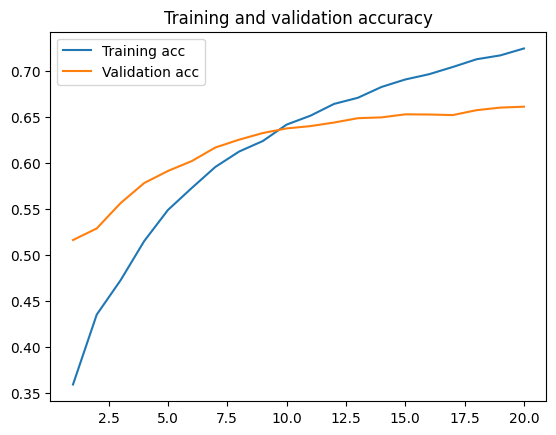

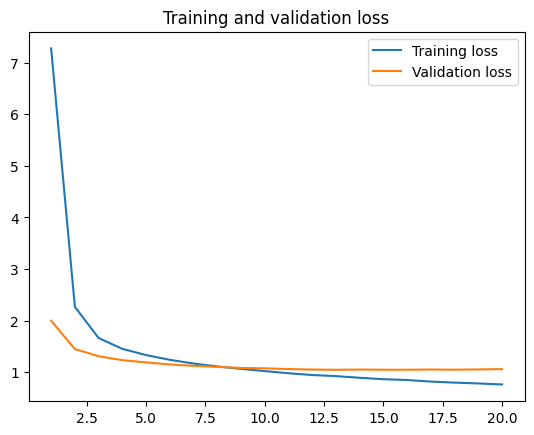

In [108]:
import matplotlib.pyplot as plt

acc = history_vgg.history['accuracy']
val_acc = history_vgg.history['val_accuracy']
loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [109]:
test_loss, test_acc = model.evaluate(x_test_features, y_test)
print(f"VGG16 test accuracy: {test_acc:.4f}")
print(f"VGG16 training time was {vgg_end - vgg_start:.2f}")

test_loss, test_acc = model_cnn.evaluate(x_test, y_test)
print(f"CNN test accuracy: {test_acc:.4f}")
print(f"CNN training time was {cnn_end - cnn_start:.2f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6580 - loss: 1.0742
VGG16 test accuracy: 0.6580
VGG16 training time was 46.04
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6774 - loss: 1.0712
CNN test accuracy: 0.6774
CNN training time was 57.25


# Pohdinta

Tässä harjoituksessa vertailin kahta erilaista lähestymistapaa CIFAR-10-datasetin kuvien luokitteluun. Alusta asti koulutettua konvoluutioneuroverkko (CNN) ja esikoulutettua VGG16-mallia, jota käytin piirteiden irrottamiseen (Feature Extraction)

Tulosten perusteella CNN saavutti hieman paremman testitarkkuudeen (67,74 %) kuin VGG16-malli (65,80 %).

Koulutusajassa VGG16-malli oli nopeampi (46,04 s), kun taas CNN-mallin kouluttaminen vei enemmän aikaa (57,25 s).




# Yhteenveto

VGG16-malli on erittäin tehokas ajankäytön suhteen, mutta sen etu tarkkuudessa ei tullut tässä harjoituksessa esiin datasetin pienestä kuvakoon vuoksi. CNN pystyi oppimaan piirteitä paremmin matalan resoluution kuvilla.

Jos kuvien resoluutio olisi suurempi, esikoulutettu malli todennäköisesti voittaisi molemmilla osa-alueilla.